In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [13]:
# интенсивность входящего потока
lam = 5  

# параметры RPC и ответа
mu_rpc = 30
mu_resp = 40

# размер данных
n = 1000000

# время моделирования
T = 10000


# типы команд
command_types = ["GET", "SEARCH", "UPDATE", "ANALYTICS"]

# вероятность появления команды
command_probabilities = [0.5, 0.3, 0.15, 0.05]

In [14]:
def generate_execution_time(command, n):
    if command == "GET":
        scale = 0.002
    elif command == "SEARCH":
        scale = np.log(n) * 0.002
    elif command == "UPDATE":
        scale = n * 0.000002
    elif command == "ANALYTICS":
        scale = (n**2) * 0.000000002

    return np.random.exponential(scale)

In [15]:
def theoretical_values(lam, mu):

    rho = lam / mu

    P0 = mu / (lam + mu)
    P1 = lam / (lam + mu)

    Q = P0
    A = lam * Q

    W = 1 / mu
    L = rho

    return {
        "rho": rho,
        "P0": P0,
        "P1": P1,
        "Q": Q,
        "A": A,
        "W": W,
        "L": L
    }

theoretical_values(lam, mu)

NameError: name 'mu' is not defined

In [16]:
def simulate_system(lam, mu_rpc, mu_resp, T, n):

    current_time = 0
    server_free_time = 0

    arrived = 0
    served = 0
    rejected = 0

    busy_time = 0

    command_stats = {
        "GET": [],
        "SEARCH": [],
        "UPDATE": [],
        "ANALYTICS": []
    }

    while current_time < T:

        # генерация новой заявки
        interarrival = np.random.exponential(1 / lam)
        current_time += interarrival

        if current_time > T:
            break

        arrived += 1

        # выбираем тип команды
        command = np.random.choice(command_types, p=command_probabilities)

        # времена этапов обработки
        rpc_time = np.random.exponential(1 / mu_rpc)
        exec_time = generate_execution_time(command, n)
        resp_time = np.random.exponential(1 / mu_resp)

        service_time = rpc_time + exec_time + resp_time

        if current_time >= server_free_time:

            served += 1
            server_free_time = current_time + service_time

            busy_time += service_time

            command_stats[command].append(exec_time)

        else:

            rejected += 1

    utilization = busy_time / T

    return {
        "arrived": arrived,
        "served": served,
        "rejected": rejected,
        "refusal_probability": rejected / arrived,
        "utilization": utilization,
        "command_stats": command_stats
    }

In [17]:
result = simulate_system(lam, mu_rpc, mu_resp, T, n)

print("Arrived:", result["arrived"])
print("Served:", result["served"])
print("Rejected:", result["rejected"])
print("Refusal probability:", result["refusal_probability"])
print("Utilization:", result["utilization"])

Arrived: 49597
Served: 165
Rejected: 49432
Refusal probability: 0.9966731858781781
Utilization: 1.0043056675342001


In [18]:
avg_times = {}

for cmd in command_types:
    data = result["command_stats"][cmd]
    
    if len(data) > 0:
        avg_times[cmd] = np.mean(data)
    else:
        avg_times[cmd] = 0

df = pd.DataFrame.from_dict(avg_times, orient="index", columns=["Avg execution time"])
df

,Avg execution time
GET,0.001725
SEARCH,0.032074
UPDATE,1.823814
ANALYTICS,1665.400397


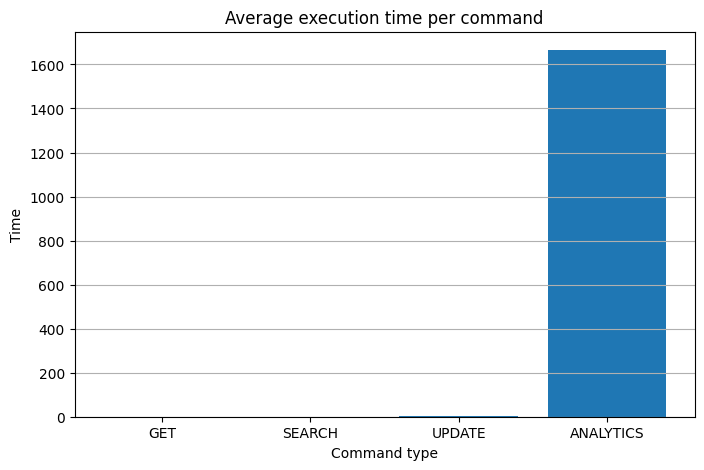

In [19]:
plt.figure(figsize=(8,5))

plt.bar(avg_times.keys(), avg_times.values())

plt.title("Average execution time per command")
plt.xlabel("Command type")
plt.ylabel("Time")

plt.grid(axis="y")

plt.show()

In [20]:
lambdas = np.linspace(1, 15, 20)

refusal_probs = []

for l in lambdas:

    r = simulate_system(l, mu_rpc, mu_resp, T, n)

    refusal_probs.append(r["refusal_probability"])

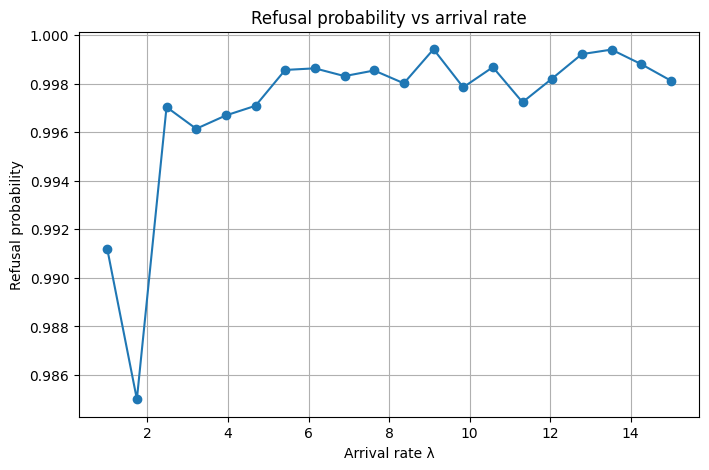

In [21]:
plt.figure(figsize=(8,5))

plt.plot(lambdas, refusal_probs, marker="o")

plt.title("Refusal probability vs arrival rate")
plt.xlabel("Arrival rate λ")
plt.ylabel("Refusal probability")

plt.grid()

plt.show()